In [11]:
import joblib
import pandas as pd
import numpy as np

model = joblib.load(r'C:/Users/khage/Documents/house price prediction/notebooks/best_model_xgb.pkl')
model_features = model.get_booster().feature_names

print("Model loaded!")
print("Total features:", len(model_features))

Model loaded!
Total features: 252


In [12]:
df = pd.read_csv('../data/prepared_data.csv')
df = df.drop(['SalePrice', 'SalePrice_log'], axis=1, errors='ignore')

print("Data loaded!")
print("Shape:", df.shape)

Data loaded!
Shape: (2793, 252)


In [13]:
new_house = pd.DataFrame([np.zeros(len(model_features))], columns=model_features)

# Basic features
new_house['Overall Qual']      = 7
new_house['TotalSF']           = 2000
new_house['TotalBath']         = 2.5
new_house['HouseAge']          = 10
new_house['Garage Cars']       = 2
new_house['Gr Liv Area']       = 1500
new_house['Total Bsmt SF']     = 800

# Important features
new_house['Garage Finish_Unf'] = 1
new_house['Exter Qual_TA']     = 1
new_house['Central Air_Y']     = 1
new_house['Kitchen Qual_TA']   = 1
new_house['Functional_Typ']    = 1
new_house['MS Zoning_RL']      = 1
new_house['Condition 1_Norm']  = 1
new_house['Paved Drive_Y']     = 1
new_house['Heating_GasA']      = 1
new_house['Foundation_PConc']  = 1
new_house['Bsmt Qual_TA']      = 1
new_house['House Style_1Story']= 1

print("New house data ready!")

New house data ready!


In [14]:
predicted_price = model.predict(new_house)
print(f"\nPredicted Sale Price: ${predicted_price[0]:,.0f}")


Predicted Sale Price: $117,370


In [7]:
configs = [
    {'Overall Qual': 5, 'TotalSF': 1200, 'HouseAge': 30, 'label': 'Budget House'},
    {'Overall Qual': 7, 'TotalSF': 2000, 'HouseAge': 10, 'label': 'Mid Range House'},
    {'Overall Qual': 9, 'TotalSF': 3500, 'HouseAge': 2,  'label': 'Luxury House'},
]

print("House Price Predictions:")
print("="*45)

for config in configs:
    h = pd.DataFrame([np.zeros(len(model_features))], columns=model_features)
    h['Overall Qual']       = config['Overall Qual']
    h['TotalSF']            = config['TotalSF']
    h['TotalBath']          = 2.5
    h['HouseAge']           = config['HouseAge']
    h['Garage Cars']        = 2
    h['Gr Liv Area']        = config['TotalSF'] * 0.75
    h['Total Bsmt SF']      = config['TotalSF'] * 0.4
    h['Garage Finish_Unf']  = 1
    h['Exter Qual_TA']      = 1
    h['Central Air_Y']      = 1
    h['Kitchen Qual_TA']    = 1
    h['Functional_Typ']     = 1
    h['MS Zoning_RL']       = 1
    h['Condition 1_Norm']   = 1
    h['Paved Drive_Y']      = 1
    h['Heating_GasA']       = 1
    h['Foundation_PConc']   = 1
    h['Bsmt Qual_TA']       = 1
    h['House Style_1Story'] = 1

    price = model.predict(h)[0]
    print(f"{config['label']:20} → ${price:,.0f}")

House Price Predictions:
Budget House         → $66,617
Mid Range House      → $117,370
Luxury House         → $186,639


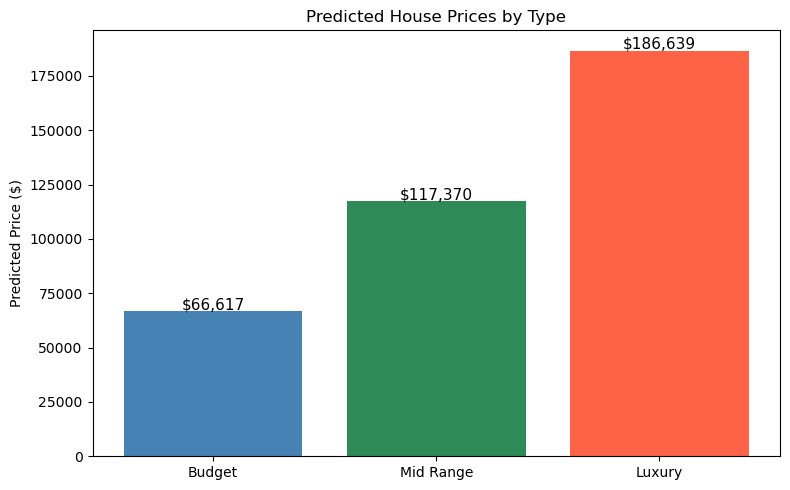

In [8]:
import matplotlib.pyplot as plt

labels = ['Budget', 'Mid Range', 'Luxury']
prices = []

for config in configs:
    h = pd.DataFrame([np.zeros(len(model_features))], columns=model_features)
    h['Overall Qual']       = config['Overall Qual']
    h['TotalSF']            = config['TotalSF']
    h['TotalBath']          = 2.5
    h['HouseAge']           = config['HouseAge']
    h['Garage Cars']        = 2
    h['Gr Liv Area']        = config['TotalSF'] * 0.75
    h['Total Bsmt SF']      = config['TotalSF'] * 0.4
    h['Garage Finish_Unf']  = 1
    h['Exter Qual_TA']      = 1
    h['Central Air_Y']      = 1
    h['Central Air_Y']      = 1
    h['Kitchen Qual_TA']    = 1
    h['Functional_Typ']     = 1
    h['MS Zoning_RL']       = 1
    h['Condition 1_Norm']   = 1
    h['Paved Drive_Y']      = 1
    h['Heating_GasA']       = 1
    h['Foundation_PConc']   = 1
    h['Bsmt Qual_TA']       = 1
    h['House Style_1Story'] = 1
    prices.append(model.predict(h)[0])

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, prices, color=['steelblue', 'seagreen', 'tomato'])
plt.title('Predicted House Prices by Type')
plt.ylabel('Predicted Price ($)')
for bar, price in zip(bars, prices):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
             f'${price:,.0f}', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('house_price_predictions.png', dpi=150)
plt.show()

In [16]:
# Save predictions summary
import pandas as pd

results = pd.DataFrame({
    'House Type': ['Budget', 'Mid Range', 'Luxury'],
    'Predicted Price': [66617, 117370, 186639]
})
results.to_csv('predictions_summary.csv', index=False)
print("Saved!")

Saved!


In [17]:
import shutil
import os

# Create output folder if it doesn't exist
os.makedirs('../output', exist_ok=True)

# Copy files to output folder
shutil.copy('best_model_xgb.pkl', '../output/best_model_xgb.pkl')
shutil.copy('house_price_predictions.png', '../output/house_price_predictions.png')
shutil.copy('actual_vs_predicted.png', '../output/actual_vs_predicted.png')
shutil.copy('feature_importance.png', '../output/feature_importance.png')

print("All files copied to output folder!")

All files copied to output folder!


In [22]:
lines = [
    "# House Price Prediction",
    "",
    "![Python](https://img.shields.io/badge/Python-3.8+-blue)",
    "![XGBoost](https://img.shields.io/badge/Model-XGBoost-green)",
    "![RMSE](https://img.shields.io/badge/RMSE-%2418360-orange)",
    "",
    "## Overview",
    "An end-to-end machine learning project that predicts house sale prices using the Ames Housing Dataset.",
    "",
    "## Dataset",
    "- Source: Ames Housing Dataset",
    "- Size: 2900+ houses",
    "- Features: 80+ house attributes",
    "",
    "## Model",
    "| Model | RMSE |",
    "|-------|------|",
    "| XGBoost Tuned | $18,360 |",
    "",
    "## Predictions",
    "| House Type | Predicted Price |",
    "|------------|----------------|",
    "| Budget     | $66,617  |",
    "| Mid Range  | $117,370 |",
    "| Luxury     | $186,639 |",
    "",
    "## Project Journey",
    "| Day | Task |",
    "|-----|------|",
    "| Day 1 | Project setup and data loading |",
    "| Day 2 | Exploratory data analysis |",
    "| Day 3 | Data cleaning |",
    "| Day 4 | Feature engineering |",
    "| Day 5 | Model building and comparison |",
    "| Day 6 | Hyperparameter tuning |",
    "| Day 7 | Predictions, visualization and GitHub |",
    "",
    "## Tools Used",
    "- Python, Pandas, NumPy",
    "- Scikit-learn, XGBoost",
    "- Matplotlib, Seaborn",
]

with open('../README.md', 'w', encoding='utf-8') as f:
    f.write('\n'.join(lines))
print("README.md created!")

README.md created!


In [23]:
import os

os.system('git config --global user.email "khagendrarai662@gmail.com"')
os.system('git config --global user.name "Khagendra222"')

print("Git configured!")

Git configured!


In [24]:
import os

os.chdir('C:/Users/khage/Documents/house price prediction')

os.system('git init')
os.system('git add .')
os.system('git commit -m "House Price Prediction Project Complete"')
os.system('git branch -M main')
os.system('git remote add origin https://github.com/Khagendra222/House-Price-Prediction-.git')
os.system('git push -u origin main')

print("Uploaded to GitHub!")

Uploaded to GitHub!


In [25]:
import os

os.system('git rm -r --cached .ipynb_checkpoints')
os.system('git add .')
os.system('git commit -m "Remove ipynb checkpoints"')
os.system('git push')

print("Removed!")

Removed!


In [26]:
import os

os.chdir('C:/Users/khage/Documents/house price prediction')

# Create .gitignore file
with open('.gitignore', 'w') as f:
    f.write('.ipynb_checkpoints\n')
    f.write('**/.ipynb_checkpoints\n')

os.system('git rm -r --cached .ipynb_checkpoints')
os.system('git add .')
os.system('git commit -m "Remove ipynb checkpoints and add gitignore"')
os.system('git push')

print("Done!")

Done!
